In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
!pip install shap lime scikit-image -q

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [19]:
input_shape = (128,128,3)
batch_size = 32
epochs_stage1 = 5
epochs_stage2 = 5
num_classes = 8

patch_size = 16
projection_dim = 64
transformer_layers = 4
num_heads = 8

In [20]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/datasets/amimulahasanrofik/alz-b-1100/alzheimer_new_11/alzheimer_new",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/datasets/amimulahasanrofik/alz-b-1100/alzheimer_new_11/alzheimer_new",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=batch_size
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 8800 files belonging to 8 classes.
Using 7040 files for training.
Found 8800 files belonging to 8 classes.
Using 1760 files for validation.


In [21]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=tf.shape(patch)[1], delta=1)
        return self.projection(patch) + self.position_embedding(positions)

In [22]:
def build_model():
    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])(inputs)

    # CNN
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    x_base = base_model(x_aug)
    base_model.trainable = False
    x_cnn = layers.GlobalAveragePooling2D()(x_base)

    # ViT
    num_patches = (input_shape[0]//patch_size)**2
    x = layers.Rescaling(1./255)(x_aug)
    patches = Patches(patch_size)(x)
    encoded = PatchEncoder(num_patches, projection_dim)(patches)

    for i in range(transformer_layers):
        x1 = layers.LayerNormalization()(encoded)
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim,
            name=f"vit_attention_{i}"
        )(x1,x1)
        x2 = layers.Add()([attn, encoded])
        x3 = layers.LayerNormalization()(x2)
        encoded = layers.Add()([x3,x2])

    x_vit = layers.LayerNormalization()(encoded)
    x_vit = layers.Reshape((num_patches, projection_dim))(x_vit)
    x_vit = layers.GRU(256)(x_vit)

    # Merge
    x = layers.concatenate([x_cnn, x_vit])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()

In [23]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=epochs_stage1)

# Fine-tune
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=epochs_stage2)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.6777 - loss: 0.8923 - val_accuracy: 0.8722 - val_loss: 0.3256
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.8627 - loss: 0.3678 - val_accuracy: 0.8830 - val_loss: 0.2985
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9024 - loss: 0.2746 - val_accuracy: 0.8653 - val_loss: 0.3701
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9166 - loss: 0.2317 - val_accuracy: 0.9102 - val_loss: 0.2310
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9234 - loss: 0.2131 - val_accuracy: 0.9216 - val_loss: 0.2227
Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.8030 - loss: 0.6685 - val_accuracy: 0.9222 - val_loss: 0.2398
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.9288 - loss: 0.2158 - val_accuracy: 0.9369 - val_loss: 0.2049
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.9491 - loss: 0.1509 - val_accu

In [24]:
img_path = "/kaggle/input/datasets/amimulahasanrofik/alz-b-1100/alzheimer_new_11/alzheimer_new/MildDemented/OAS1_0028_MR1_mpr-1_103.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img, axis=0)

In [25]:
def gradcam_fixed():

    # ✅ Step 1: নতুন CNN model (same weights)
    cnn_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(128,128,3)
    )

    # trained weights copy (IMPORTANT)
    cnn_model.set_weights(base_model.get_weights())

    last_conv = "conv5_block3_out"

    grad_model = tf.keras.models.Model(
        inputs=cnn_model.input,
        outputs=[
            cnn_model.get_layer(last_conv).output,
            cnn_model.output
        ]
    )

    # ✅ Step 2: input tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)

        # fake classifier output (use mean feature)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # ✅ Save heatmap
    plt.imshow(heatmap, cmap='jet')
    plt.savefig("gradcam.png")
    plt.close()

    # ✅ Overlay
    img_raw = cv2.imread(img_path)
    heatmap_resized = cv2.resize(heatmap,(img_raw.shape[1],img_raw.shape[0]))
    heatmap_resized = np.uint8(255*heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_raw,0.6,heatmap_color,0.4,0)

    cv2.imwrite("gradcam_overlay.png", overlay)

gradcam_fixed()

In [28]:
# 🔥 Extract Attention
att_layer = None
for layer in model.layers:
    if "vit_attention" in layer.name:
        att_layer = layer

att_model = keras.Model(model.input, att_layer.output)

att = att_model.predict(img_array)

# 👉 FIX: reduce channel dimension properly
att = np.mean(att[0], axis=-1)   # (64,)

# 👉 FIX: reshape to 2D (8x8)
grid_size = int(np.sqrt(att.shape[0]))  # 8
att = att.reshape(grid_size, grid_size)

# 👉 upscale to image size
att = cv2.resize(att, (128,128))

# 👉 normalize
att = (att - att.min()) / (att.max() - att.min() + 1e-8)

# 👉 plot
plt.imshow(att, cmap='viridis')
plt.colorbar()
plt.savefig("attention.png")
plt.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step


In [31]:
# 1️⃣ Original image
img_raw = cv2.imread(img_path)  # shape (H, W, 3)

# 2️⃣ Attention map resize
att_resized = cv2.resize(att, (img_raw.shape[1], img_raw.shape[0]))

# 3️⃣ Convert to 3 channels
att_color = cv2.applyColorMap(np.uint8(255*att_resized), cv2.COLORMAP_VIRIDIS)

# 4️⃣ Ensure same dtype
img_raw = np.uint8(img_raw)
att_color = np.uint8(att_color)

# 5️⃣ Overlay
overlay = cv2.addWeighted(img_raw, 0.6, att_color, 0.4, 0)

# 6️⃣ Save
cv2.imwrite("attention_overlay.png", overlay)

True

In [30]:
# att_layer = model.get_layer("vit_attention_3")
# att_model = keras.Model(model.input, att_layer.output)

# att = att_model.predict(img_array)
# att = np.mean(att[0], axis=-1)

# plt.imshow(att, cmap='viridis')
# plt.savefig("attention.png")
# plt.close()

In [32]:
for images,_ in train_ds.take(1):
    background = images[:20]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(img_array)

shap.image_plot(shap_values, img_array, show=False)
plt.savefig("shap.png")
plt.close()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_817
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_817
Received: inputs=['Tensor(shape=(50, 128, 128, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.4516127672977746e-08..4.9059963203035295e-08].


In [33]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_array[0].astype('double'),
    model.predict,
    top_labels=1,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5
)

plt.imshow(mark_boundaries(temp, mask))
plt.savefig("lime.png")
plt.close()

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━

In [34]:
baseline = tf.zeros_like(img_array)
steps = 50

interpolated = [baseline + (i/steps)*(img_array-baseline) for i in range(steps)]

grads = []
for x in interpolated:
    with tf.GradientTape() as tape:
        tape.watch(x)
        pred = model(x)
        loss = tf.reduce_max(pred)
    grads.append(tape.gradient(loss, x))

avg = tf.reduce_mean(grads, axis=0)
ig = (img_array - baseline)*avg

plt.imshow(ig[0])
plt.savefig("ig.png")
plt.close()

I0000 00:00:1774030891.347413      55 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x425a0c10
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00088065077..0.00047401362].


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


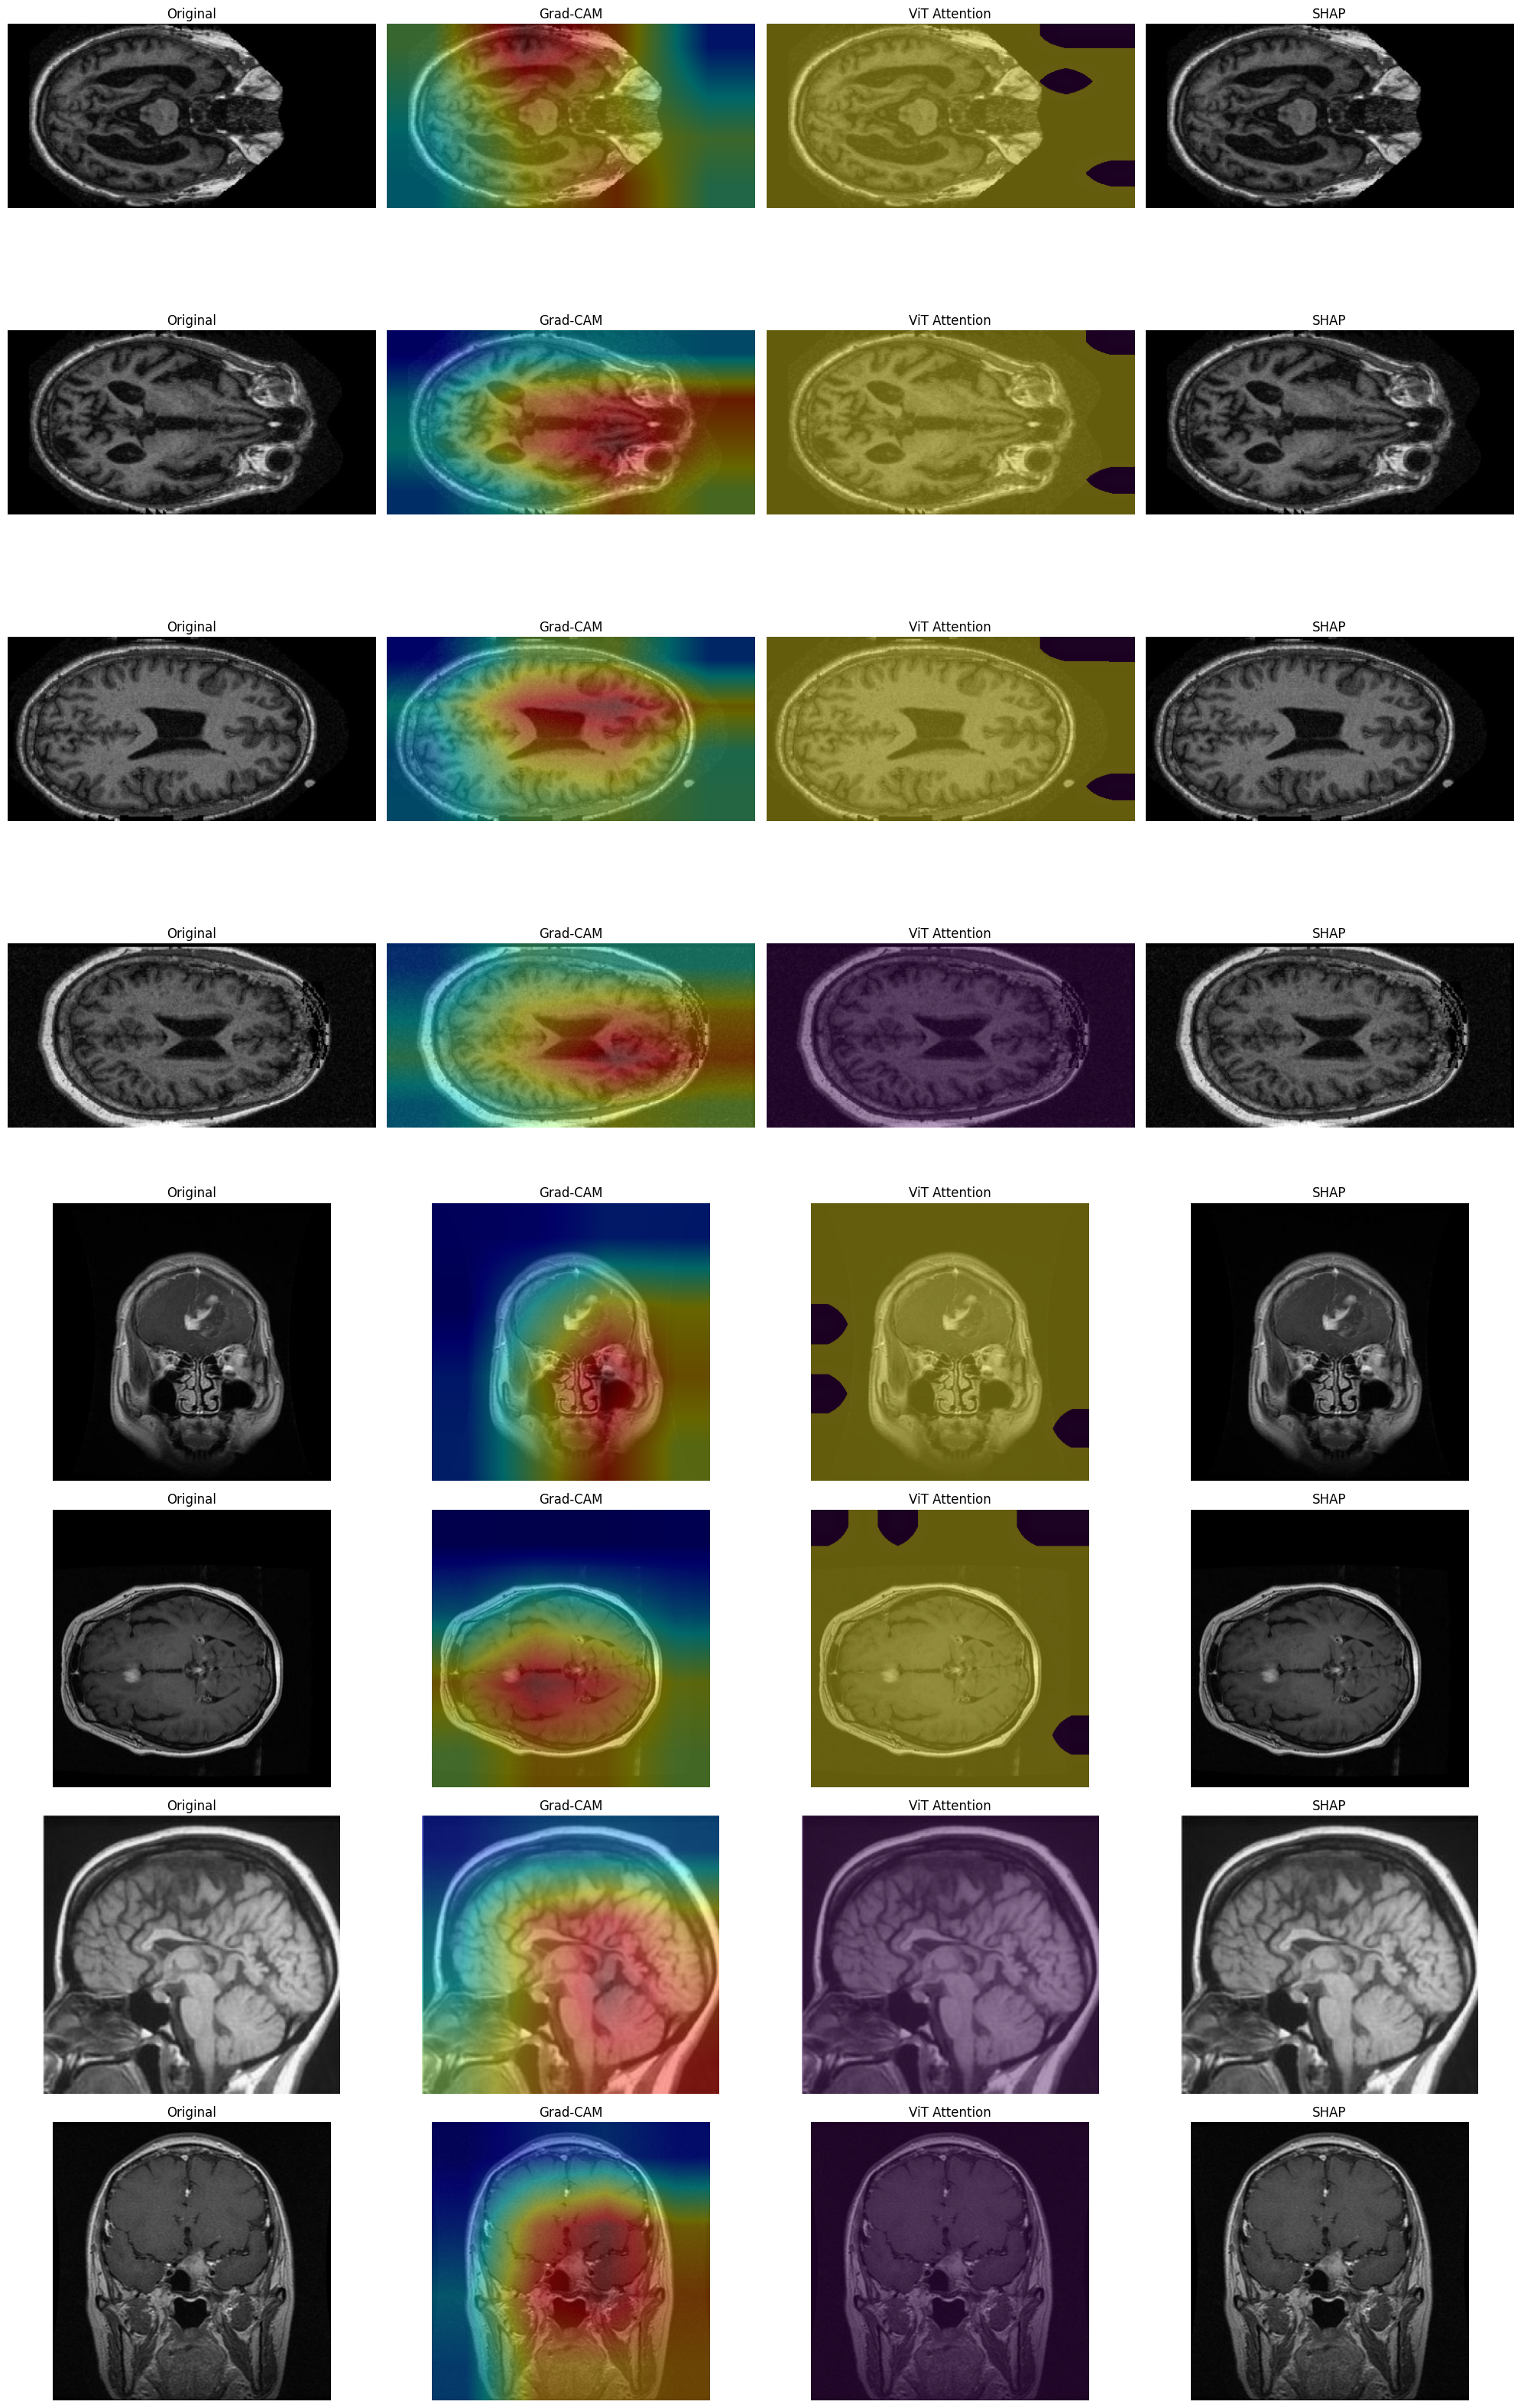

In [36]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ---------------- Settings ----------------
dataset_path = "/kaggle/input/datasets/amimulahasanrofik/alz-b-1100/alzheimer_new_11/alzheimer_new"
class_names = sorted(os.listdir(dataset_path))
n_classes = len(class_names)
patch_size = 16

# ---------------- Select one image per class ----------------
images_per_class = []
for cls in class_names:
    cls_path = os.path.join(dataset_path, cls)
    imgs = os.listdir(cls_path)
    # pick first image for demo
    images_per_class.append(os.path.join(cls_path, imgs[0]))

# ---------------- Preprocess images ----------------
img_arrays = []
for path in images_per_class:
    img = keras.preprocessing.image.load_img(path, target_size=(128,128))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_arrays.append(img_array)

# ---------------- Grad-CAM function ----------------
def gradcam_overlay_func(img_array, model, base_model, last_conv="conv5_block3_out"):
    cnn_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
    cnn_model.set_weights(base_model.get_weights())
    grad_model = keras.Model(
        inputs=cnn_model.input,
        outputs=[cnn_model.get_layer(last_conv).output, cnn_model.output]
    )
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = tf.reduce_mean(predictions)
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap + 1e-8)
    heatmap = heatmap.numpy()
    return heatmap

# ---------------- Attention function ----------------
def attention_overlay_func(img_array, att_model, img_raw):
    att = att_model.predict(img_array)
    att = np.mean(att[0], axis=-1)
    grid_size = int(np.sqrt(att.shape[0]))
    att = att.reshape(grid_size, grid_size)
    att_resized = cv2.resize(att, (img_raw.shape[1], img_raw.shape[0]))
    att_color = cv2.applyColorMap(np.uint8(255*att_resized), cv2.COLORMAP_VIRIDIS)
    overlay = cv2.addWeighted(img_raw, 0.6, att_color, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay

# ---------------- SHAP placeholder ----------------
# (replace with actual SHAP overlay if already computed)
def shap_placeholder(img_raw):
    return cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# ---------------- Build attention model ----------------
att_layer = None
for layer in model.layers:
    if "vit_attention" in layer.name:
        att_layer = layer
att_model = keras.Model(model.input, att_layer.output)

# ---------------- Generate 8-class figure ----------------
cols = 4
fig, axs = plt.subplots(n_classes, cols, figsize=(20, 4*n_classes))

for i in range(n_classes):
    img_path = images_per_class[i]
    img_raw = cv2.imread(img_path)
    
    # ---------------- Original ----------------
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    
    # ---------------- Grad-CAM ----------------
    gradcam_heatmap = gradcam_overlay_func(img_arrays[i], model, base_model)
    gradcam_resized = cv2.resize(gradcam_heatmap, (img_raw.shape[1], img_raw.shape[0]))
    gradcam_color = cv2.applyColorMap(np.uint8(255*gradcam_resized), cv2.COLORMAP_JET)
    gradcam_overlay = cv2.addWeighted(img_raw, 0.6, gradcam_color, 0.4, 0)
    gradcam_overlay = cv2.cvtColor(gradcam_overlay, cv2.COLOR_BGR2RGB)
    
    # ---------------- Attention ----------------
    att_overlay = attention_overlay_func(img_arrays[i], att_model, img_raw)
    
    # ---------------- SHAP ----------------
    shap_overlay = shap_placeholder(img_raw)
    
    # ---------------- Plot ----------------
    axs[i,0].imshow(img_rgb)
    axs[i,0].set_title("Original")
    axs[i,0].axis('off')
    
    axs[i,1].imshow(gradcam_overlay)
    axs[i,1].set_title("Grad-CAM")
    axs[i,1].axis('off')
    
    axs[i,2].imshow(att_overlay)
    axs[i,2].set_title("ViT Attention")
    axs[i,2].axis('off')
    
    axs[i,3].imshow(shap_overlay)
    axs[i,3].set_title("SHAP")
    axs[i,3].axis('off')

plt.tight_layout()
plt.savefig("8class_xai_figure.png", dpi=300)
plt.show()

In [38]:
# যদি আগে train করো নি:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

ValueError: You must call `compile()` before using the model.

In [37]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

# ---------------- Input Image ----------------
img_path = "/kaggle/input/datasets/amimulahasanrofik/alz-b-1100/alzheimer_new_11/alzheimer_new/MildDemented/OAS1_0028_MR1_mpr-1_107.jpg"  # replace with your image
img_raw = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

img_array = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = tf.keras.preprocessing.image.img_to_array(img_array)
img_array = np.expand_dims(img_array, axis=0)/255.0

# ---------------- Build Model ----------------
# Use your trained model (ResNet50+ViT+GRU)
model, base_model = build_model()  # your previously defined function
model.load_weights("best_model.h5")

# ---------------- 1. Grad-CAM ----------------
def gradcam(model, img_array, last_conv_layer="conv5_block3_out"):
    grad_model = Model(
        [model.inputs], [model.get_layer(last_conv_layer).output, model.output]
    )
    img_tensor = tf.convert_to_tensor(img_array)
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, tf.argmax(predictions[0])]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap,0)
    heatmap /= tf.reduce_max(heatmap)+1e-8
    heatmap = heatmap.numpy()
    
    heatmap = cv2.resize(heatmap, (img_raw.shape[1], img_raw.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_raw, 0.6, heatmap_color, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay

gradcam_overlay = gradcam(model, img_array)

# ---------------- 2. ViT Attention ----------------
# assuming you have named attention layer in ViT branch
att_layer_name = "multi_head_attention"  # replace with your ViT attention layer name
att_layer = model.get_layer(att_layer_name)
att_model = Model(model.input, att_layer.output)

att = att_model.predict(img_array)
att = np.mean(att[0], axis=-1)  # average heads
patch_size = int(np.sqrt(att.shape[0]))
att = att.reshape(patch_size, patch_size)
att_resized = cv2.resize(att, (img_raw.shape[1], img_raw.shape[0]))
att_color = cv2.applyColorMap(np.uint8(255*att_resized), cv2.COLORMAP_VIRIDIS)
attention_overlay = cv2.addWeighted(img_raw, 0.6, att_color, 0.4, 0)
attention_overlay = cv2.cvtColor(attention_overlay, cv2.COLOR_BGR2RGB)

# ---------------- 3. Plot ----------------
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gradcam_overlay)
plt.title("Grad-CAM (Tumor Area)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(attention_overlay)
plt.title("ViT Attention")
plt.axis("off")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'best_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)